In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:

# PROJECT PATHS


current_folder = Path.cwd()

project_folder = current_folder.parent

results_folder = project_folder / "06_Results"

print("Current folder:")
print(current_folder)

print("\nProject folder:")
print(project_folder)

print("\nResults folder:")
print(results_folder)

print("\nResults folder exists:")
print(results_folder.exists())

Current folder:
/Users/abhishekkharat/Documents/MSc_LBM_Project/05_Python_Analysis

Project folder:
/Users/abhishekkharat/Documents/MSc_LBM_Project

Results folder:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results

Results folder exists:
True


In [5]:

# FIND ALL CSV RESULT FILES


csv_files = sorted(results_folder.rglob("*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

print("\nCSV files:")
for file in csv_files:
    print(file.relative_to(project_folder))

Number of CSV files found: 16

CSV files:
06_Results/1D_Benchmark/1D_benchmark_profiles.csv
06_Results/1D_Benchmark/1D_benchmark_summary.csv
06_Results/1D_Diffusion/1D_diffusion_profiles.csv
06_Results/1D_Diffusion/1D_diffusion_summary.csv
06_Results/1D_Low_Diffusion_Diagnostic/1D_low_diffusion_case_summary.csv
06_Results/1D_Low_Diffusion_Diagnostic/1D_low_diffusion_snapshot_summary.csv
06_Results/1D_Velocity/1D_velocity_profiles.csv
06_Results/1D_Velocity/1D_velocity_summary.csv
06_Results/2D_Benchmark/2D_benchmark_profiles.csv
06_Results/2D_Benchmark/2D_benchmark_summary.csv
06_Results/2D_Channel_Width/2D_channel_width_summary.csv
06_Results/2D_Diffusion/2D_diffusion_summary.csv
06_Results/2D_Multiple_Sources/2D_multiple_sources_source_locations.csv
06_Results/2D_Multiple_Sources/2D_multiple_sources_summary.csv
06_Results/2D_Transient_Diagnostic/2D_transient_diagnostic_summary.csv
06_Results/2D_Velocity/2D_velocity_summary.csv


In [7]:

# LOAD ALL MAIN SUMMARY DATASETS


benchmark_1d = pd.read_csv(
    results_folder / "1D_Benchmark" / "1D_benchmark_summary.csv"
)

diffusion_1d = pd.read_csv(
    results_folder / "1D_Diffusion" / "1D_diffusion_summary.csv"
)

velocity_1d = pd.read_csv(
    results_folder / "1D_Velocity" / "1D_velocity_summary.csv"
)

low_diffusion_1d = pd.read_csv(
    results_folder
    / "1D_Low_Diffusion_Diagnostic"
    / "1D_low_diffusion_case_summary.csv"
)

benchmark_2d = pd.read_csv(
    results_folder / "2D_Benchmark" / "2D_benchmark_summary.csv"
)

diffusion_2d = pd.read_csv(
    results_folder / "2D_Diffusion" / "2D_diffusion_summary.csv"
)

velocity_2d = pd.read_csv(
    results_folder / "2D_Velocity" / "2D_velocity_summary.csv"
)

channel_width_2d = pd.read_csv(
    results_folder
    / "2D_Channel_Width"
    / "2D_channel_width_summary.csv"
)

multiple_sources_2d = pd.read_csv(
    results_folder
    / "2D_Multiple_Sources"
    / "2D_multiple_sources_summary.csv"
)

transient_2d = pd.read_csv(
    results_folder
    / "2D_Transient_Diagnostic"
    / "2D_transient_diagnostic_summary.csv"
)

print("All summary datasets loaded successfully.")

All summary datasets loaded successfully.


In [9]:

# CHECK DATASET SIZES


datasets = {
    "1D Benchmark": benchmark_1d,
    "1D Diffusion": diffusion_1d,
    "1D Velocity": velocity_1d,
    "1D Low Diffusion Diagnostic": low_diffusion_1d,
    "2D Benchmark": benchmark_2d,
    "2D Diffusion": diffusion_2d,
    "2D Velocity": velocity_2d,
    "2D Channel Width": channel_width_2d,
    "2D Multiple Sources": multiple_sources_2d,
    "2D Transient Diagnostic": transient_2d,
}

for name, data in datasets.items():
    print(f"{name}: {data.shape[0]} rows x {data.shape[1]} columns")

1D Benchmark: 6 rows x 13 columns
1D Diffusion: 15 rows x 21 columns
1D Velocity: 20 rows x 21 columns
1D Low Diffusion Diagnostic: 5 rows x 11 columns
2D Benchmark: 6 rows x 23 columns
2D Diffusion: 5 rows x 23 columns
2D Velocity: 5 rows x 26 columns
2D Channel Width: 5 rows x 20 columns
2D Multiple Sources: 3 rows x 21 columns
2D Transient Diagnostic: 6 rows x 15 columns


In [11]:

# CHECK COLUMN NAMES


for name, data in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for column in data.columns:
        print(column)


1D Benchmark
Time_s
RMSE
MAE
R2
MaxAbsoluteError
MinimumConcentration
NumericalPeak
AnalyticalPeak
NumericalPeakX_m
AnalyticalPeakX_m
NumericalMass
AnalyticalMass
HasNegativeConcentration

1D Diffusion
CaseID
Diffusion
Peclet
Time_s
RMSE
MAE
R2
MaxAbsoluteError
MinimumConcentration
NumericalPeak
AnalyticalPeak
NumericalPeakX_m
AnalyticalPeakX_m
NumericalMass
AnalyticalMass
NumericalCentroidX_m
ExpectedCentroidX_m
NumericalSigma_m
TheoreticalSigma_m
HasNegativeConcentration
Runtime_seconds

1D Velocity
CaseID
Velocity
Peclet
Time_s
RMSE
MAE
R2
MaxAbsoluteError
MinimumConcentration
NumericalPeak
AnalyticalPeak
NumericalPeakX_m
AnalyticalPeakX_m
NumericalCentroidX_m
ExpectedCentroidX_m
NumericalSigma_m
TheoreticalSigma_m
NumericalMass
AnalyticalMass
HasNegativeConcentration
Runtime_seconds

1D Low Diffusion Diagnostic
Diffusion
Peclet
InitialMinimumFeq
InitialNegativePopulationCount
FirstNegativeTime_s
MostNegativeConcentration
LargestAbsoluteConcentration
FinalReachedTime_s
FinalMass
St

In [13]:

# LOAD 1D BENCHMARK PROFILE DATA


benchmark_1d_profiles = pd.read_csv(
    results_folder
    / "1D_Benchmark"
    / "1D_benchmark_profiles.csv"
)

print("1D benchmark profile shape:")
print(benchmark_1d_profiles.shape)

print("\nColumn names:")
for column in benchmark_1d_profiles.columns:
    print(column)

print("\nFirst 10 rows:")
print(benchmark_1d_profiles.head(10))

1D benchmark profile shape:
(2406, 5)

Column names:
Time_s
x_m
NumericalConcentration
AnalyticalConcentration
Error

First 10 rows:
   Time_s  x_m  NumericalConcentration  AnalyticalConcentration         Error
0    5000    0            7.298445e-11             6.075883e-10 -5.346038e-10
1    5000    1            1.442875e-10             1.101576e-09 -9.572889e-10
2    5000    2            2.821012e-10             1.977320e-09 -1.695218e-09
3    5000    3            5.454092e-10             3.513955e-09 -2.968546e-09
4    5000    4            1.042665e-09             6.182621e-09 -5.139955e-09
5    5000    5            1.970778e-09             1.076976e-08 -8.798982e-09
6    5000    6            3.682708e-09             1.857362e-08 -1.489091e-08
7    5000    7            6.803016e-09             3.171349e-08 -2.491048e-08
8    5000    8            1.242252e-08             5.361035e-08 -4.118783e-08
9    5000    9            2.242141e-08             8.972435e-08 -6.730294e-08


In [15]:

# CHECK AVAILABLE BENCHMARK TIMES


print("Available times in 1D benchmark profiles:")

print(
    sorted(
        benchmark_1d_profiles["Time_s"].unique()
    )
)

Available times in 1D benchmark profiles:
[np.int64(5000), np.int64(10000), np.int64(15000), np.int64(20000), np.int64(25000), np.int64(30000)]


In [17]:

# DISPLAY 1D BENCHMARK SUMMARY

benchmark_1d_display = benchmark_1d.copy()

benchmark_1d_display["RMSE"] = (
    benchmark_1d_display["RMSE"].map(lambda x: f"{x:.8e}")
)

benchmark_1d_display["MAE"] = (
    benchmark_1d_display["MAE"].map(lambda x: f"{x:.8e}")
)

benchmark_1d_display["R2"] = (
    benchmark_1d_display["R2"].map(lambda x: f"{x:.8f}")
)

benchmark_1d_display["NumericalMass"] = (
    benchmark_1d_display["NumericalMass"].map(lambda x: f"{x:.8f}")
)

benchmark_1d_display["AnalyticalMass"] = (
    benchmark_1d_display["AnalyticalMass"].map(lambda x: f"{x:.8f}")
)

benchmark_1d_display[
    [
        "Time_s",
        "RMSE",
        "MAE",
        "R2",
        "NumericalPeak",
        "AnalyticalPeak",
        "NumericalPeakX_m",
        "AnalyticalPeakX_m",
        "NumericalMass",
        "AnalyticalMass",
        "HasNegativeConcentration"
    ]
]

,Time_s,RMSE,MAE,R2,NumericalPeak,AnalyticalPeak,NumericalPeakX_m,AnalyticalPeakX_m,NumericalMass,AnalyticalMass,HasNegativeConcentration
0,5000,1.59912135e-04,5.23358347e-05,0.99960124,0.039964,0.039894,60,60,1.00000000,1.00000000,0
1,10000,9.46488363e-05,3.68668685e-05,0.99979418,0.028239,0.028209,110,110,1.00000000,1.00000000,0
2,15000,6.97281716e-05,3.00655162e-05,0.99985865,0.023051,0.023033,160,160,1.00000000,1.00000000,0
3,20000,5.61571712e-05,2.60238960e-05,0.99989109,0.019960,0.019947,210,210,1.00000000,1.00000000,0
4,25000,4.74853515e-05,2.32677065e-05,0.99991067,0.017852,0.017841,260,260,1.00000000,1.00000000,0
5,30000,4.14707985e-05,2.15696663e-05,0.99992357,0.016296,0.016287,310,310,1.00002354,0.99989001,0


In [19]:

# CREATE FINAL ANALYSIS RESULTS FOLDER


final_analysis_folder = results_folder / "Final_Analysis"

final_analysis_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Final analysis folder:")
print(final_analysis_folder)

Final analysis folder:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis


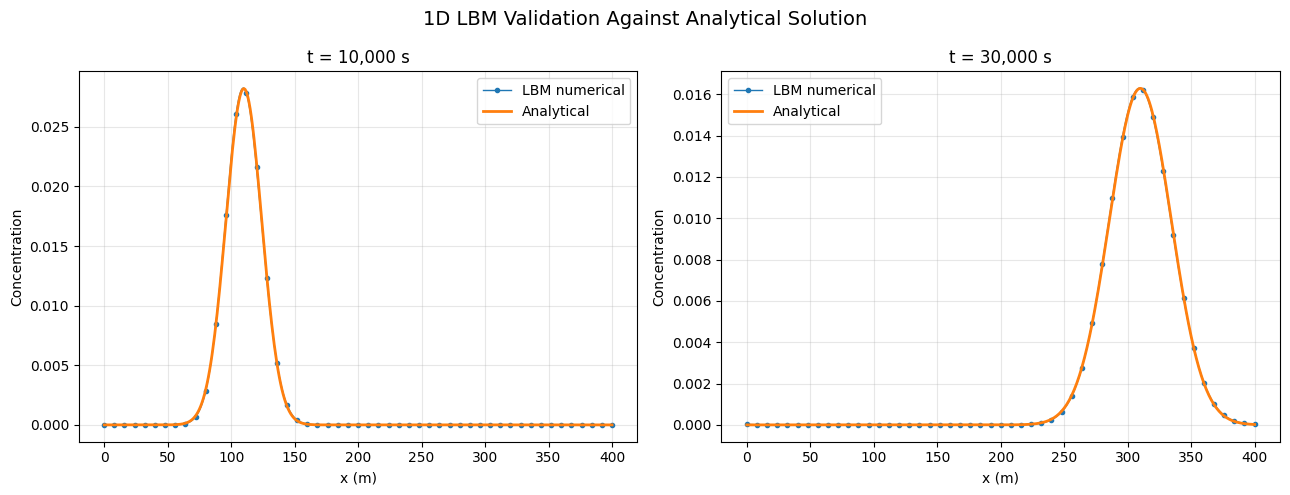

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Benchmark_Validation.png


In [21]:

# FINAL FIGURE:
# 1D NUMERICAL VS ANALYTICAL BENCHMARK


selected_times = [10000, 30000]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

for ax, time_value in zip(axes, selected_times):

    data_time = benchmark_1d_profiles[
        benchmark_1d_profiles["Time_s"] == time_value
    ]

    ax.plot(
        data_time["x_m"],
        data_time["NumericalConcentration"],
        marker="o",
        markersize=3,
        markevery=8,
        linewidth=1,
        label="LBM numerical"
    )

    ax.plot(
        data_time["x_m"],
        data_time["AnalyticalConcentration"],
        linewidth=2,
        label="Analytical"
    )

    ax.set_xlabel("x (m)")
    ax.set_ylabel("Concentration")

    ax.set_title(
        f"t = {time_value:,} s"
    )

    ax.grid(True, alpha=0.3)

    ax.legend()

fig.suptitle(
    "1D LBM Validation Against Analytical Solution",
    fontsize=14
)

fig.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Benchmark_Validation.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

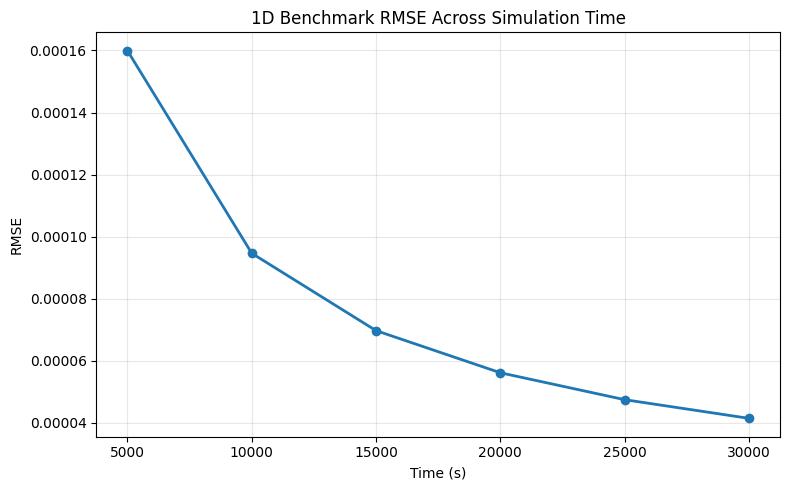

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Benchmark_RMSE.png


In [23]:

# FINAL FIGURE:
# 1D BENCHMARK RMSE VS TIME


plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_1d["Time_s"],
    benchmark_1d["RMSE"],
    marker="o",
    linewidth=2
)

plt.xlabel("Time (s)")
plt.ylabel("RMSE")

plt.title(
    "1D Benchmark RMSE Across Simulation Time"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Benchmark_RMSE.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

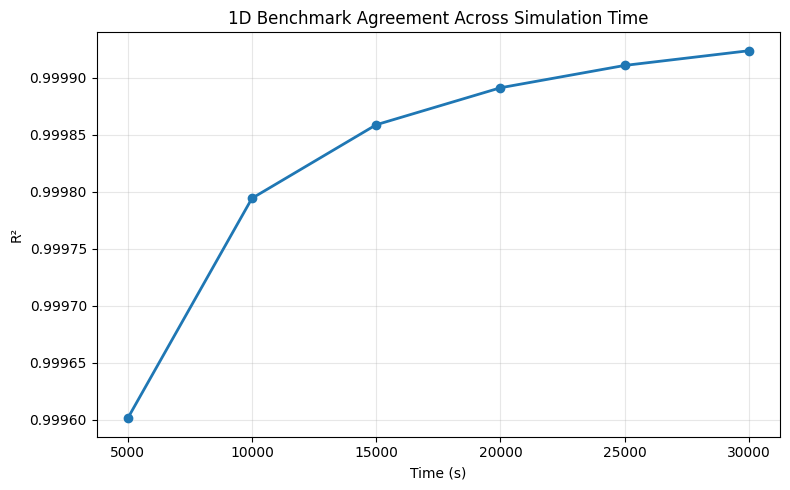

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Benchmark_R2.png


In [27]:

# FINAL FIGURE:
# 1D BENCHMARK R² VS TIME


plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_1d["Time_s"],
    benchmark_1d["R2"],
    marker="o",
    linewidth=2
)

plt.xlabel("Time (s)")
plt.ylabel("R²")

plt.title(
    "1D Benchmark Agreement Across Simulation Time"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Benchmark_R2.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [29]:

# LOAD 1D DIFFUSION PROFILE DATA


diffusion_1d_profiles = pd.read_csv(
    results_folder
    / "1D_Diffusion"
    / "1D_diffusion_profiles.csv"
)

print("1D diffusion profile shape:")
print(diffusion_1d_profiles.shape)

print("\nColumn names:")
for column in diffusion_1d_profiles.columns:
    print(column)

print("\nFirst 10 rows:")
print(diffusion_1d_profiles.head(10))

1D diffusion profile shape:
(6015, 7)

Column names:
Diffusion
Peclet
Time_s
x_m
NumericalConcentration
AnalyticalConcentration
Error

First 10 rows:
   Diffusion    Peclet  Time_s  x_m  NumericalConcentration  \
0      0.006  1.666667   10000    0           -2.756244e-60   
1      0.006  1.666667   10000    1           -3.029374e-59   
2      0.006  1.666667   10000    2           -3.329564e-58   
3      0.006  1.666667   10000    3           -3.659510e-57   
4      0.006  1.666667   10000    4           -4.022144e-56   
5      0.006  1.666667   10000    5           -4.420718e-55   
6      0.006  1.666667   10000    6           -4.858791e-54   
7      0.006  1.666667   10000    7           -5.340264e-53   
8      0.006  1.666667   10000    8           -5.869448e-52   
9      0.006  1.666667   10000    9           -6.451067e-51   

   AnalyticalConcentration         Error  
0             4.630622e-24 -4.630622e-24  
1             1.153275e-23 -1.153275e-23  
2             2.848444e-23 

In [31]:

# CHECK DIFFUSION VALUES AND TIMES


print("Diffusion values:")
print(
    sorted(
        diffusion_1d["Diffusion"].unique()
    )
)

print("\nSummary times:")
print(
    sorted(
        diffusion_1d["Time_s"].unique()
    )
)

print("\nNumber of rows for each diffusion value:")
print(
    diffusion_1d.groupby("Diffusion").size()
)

Diffusion values:
[np.float64(0.006), np.float64(0.008), np.float64(0.01), np.float64(0.015), np.float64(0.02)]

Summary times:
[np.int64(10000), np.int64(20000), np.int64(25000)]

Number of rows for each diffusion value:
Diffusion
0.006    3
0.008    3
0.010    3
0.015    3
0.020    3
dtype: int64


In [33]:

# EXTRACT REPRESENTATIVE RESULTS AT t = 20,000 s


diffusion_1d_20000 = (
    diffusion_1d[
        diffusion_1d["Time_s"] == 20000
    ]
    .sort_values("Diffusion")
    .reset_index(drop=True)
)

diffusion_1d_20000[
    [
        "Diffusion",
        "Peclet",
        "NumericalPeak",
        "AnalyticalPeak",
        "NumericalCentroidX_m",
        "ExpectedCentroidX_m",
        "NumericalSigma_m",
        "TheoreticalSigma_m",
        "RMSE",
        "R2",
        "NumericalMass",
        "HasNegativeConcentration"
    ]
]

,Diffusion,Peclet,NumericalPeak,AnalyticalPeak,NumericalCentroidX_m,ExpectedCentroidX_m,NumericalSigma_m,TheoreticalSigma_m,RMSE,R2,NumericalMass,HasNegativeConcentration
0,0.006,1.666667,0.025773,0.025752,210.0,210,15.484178,15.491933,0.000137,0.999519,1.0,0
1,0.008,1.250000,0.022316,0.022302,210.0,210,17.881826,17.888544,0.000083,0.999792,1.0,0
2,0.010,1.000000,0.019960,0.019947,210.0,210,19.993990,20.000000,0.000056,0.999891,1.0,0
3,0.015,0.666667,0.016296,0.016287,210.0,210,24.489987,24.494897,0.000028,0.999966,1.0,0
4,0.020,0.500000,0.014111,0.014105,210.0,210,28.280015,28.284271,0.000017,0.999985,1.0,0


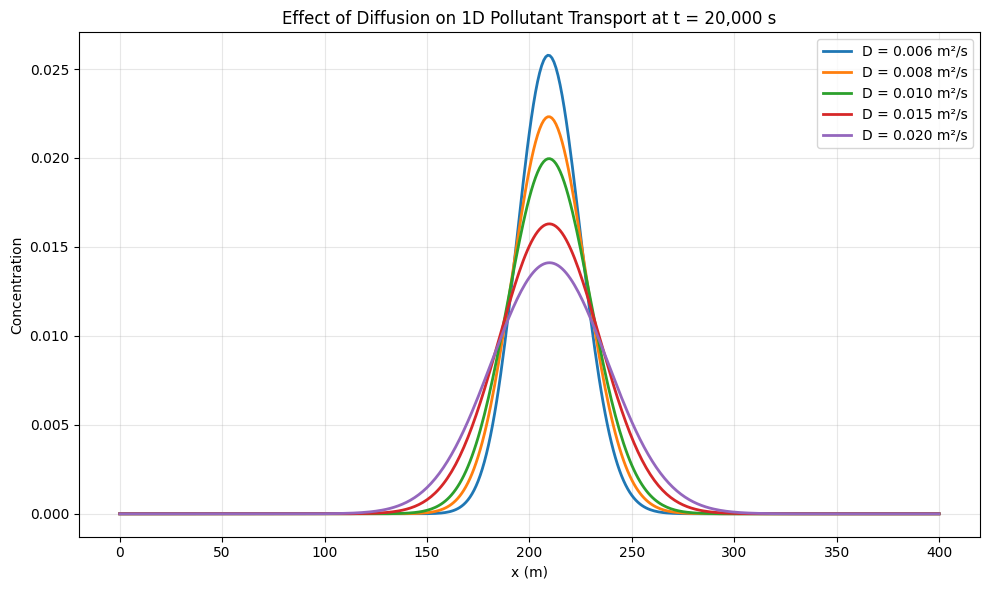

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Diffusion_Profiles.png


In [35]:

# FINAL FIGURE:
# EFFECT OF DIFFUSION ON 1D CONCENTRATION PROFILE


comparison_time = 20000

plt.figure(figsize=(10, 6))

for diffusion_value in sorted(
    diffusion_1d_profiles["Diffusion"].unique()
):

    case_data = diffusion_1d_profiles[
        (diffusion_1d_profiles["Time_s"] == comparison_time)
        &
        (diffusion_1d_profiles["Diffusion"] == diffusion_value)
    ]

    plt.plot(
        case_data["x_m"],
        case_data["NumericalConcentration"],
        linewidth=2,
        label=f"D = {diffusion_value:.3f} m²/s"
    )

plt.xlabel("x (m)")
plt.ylabel("Concentration")

plt.title(
    "Effect of Diffusion on 1D Pollutant Transport "
    "at t = 20,000 s"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Diffusion_Profiles.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

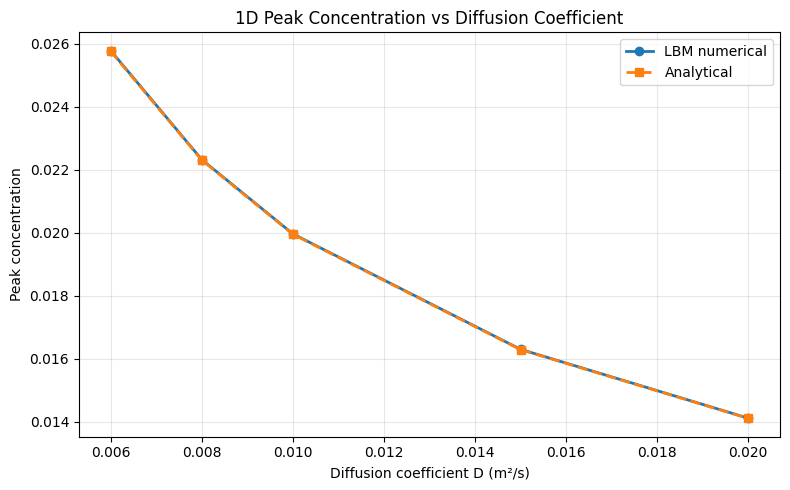

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Diffusion_Peak.png


In [37]:

# FINAL FIGURE:
# PEAK CONCENTRATION VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_1d_20000["Diffusion"],
    diffusion_1d_20000["NumericalPeak"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    diffusion_1d_20000["Diffusion"],
    diffusion_1d_20000["AnalyticalPeak"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Peak concentration")

plt.title(
    "1D Peak Concentration vs Diffusion Coefficient"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Diffusion_Peak.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

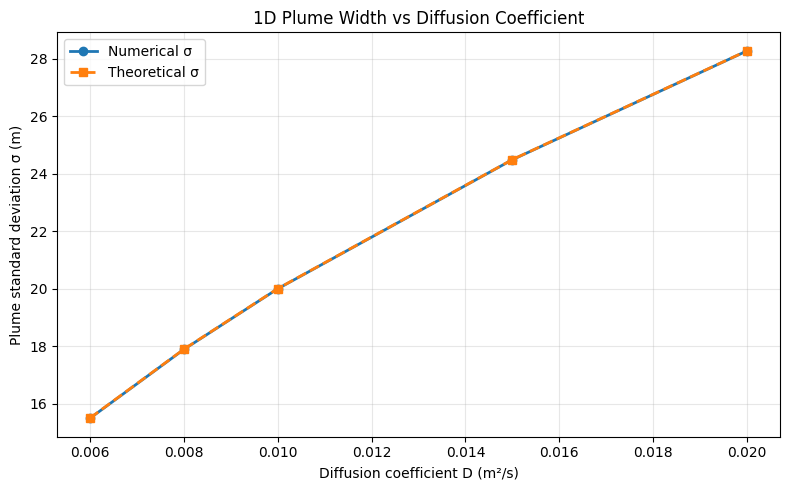

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Diffusion_Sigma.png


In [39]:

# FINAL FIGURE:
# PLUME WIDTH VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_1d_20000["Diffusion"],
    diffusion_1d_20000["NumericalSigma_m"],
    marker="o",
    linewidth=2,
    label="Numerical σ"
)

plt.plot(
    diffusion_1d_20000["Diffusion"],
    diffusion_1d_20000["TheoreticalSigma_m"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Plume standard deviation σ (m)")

plt.title(
    "1D Plume Width vs Diffusion Coefficient"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Diffusion_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

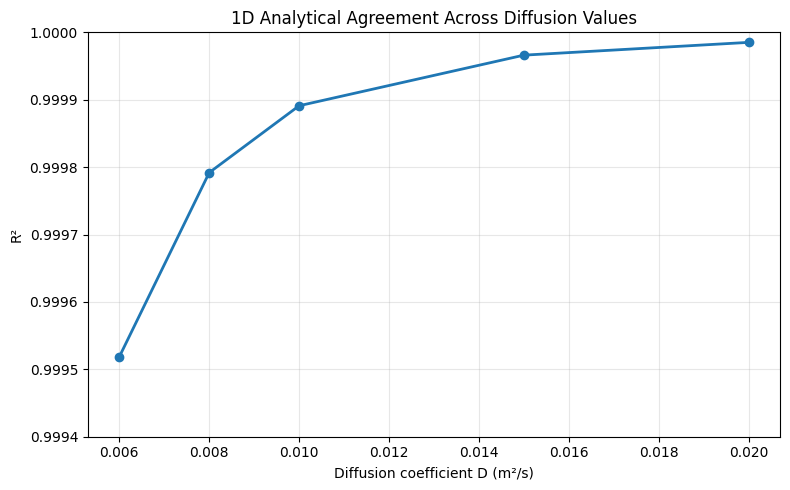

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Diffusion_R2.png


In [46]:

# FINAL FIGURE:
# R² VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_1d_20000["Diffusion"],
    diffusion_1d_20000["R2"],
    marker="o",
    linewidth=2
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("R²")

plt.title(
    "1D Analytical Agreement Across Diffusion Values"
)

plt.ylim(0.9994, 1.0000)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Diffusion_R2.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [48]:

# LOAD 1D VELOCITY PROFILE DATA


velocity_1d_profiles = pd.read_csv(
    results_folder
    / "1D_Velocity"
    / "1D_velocity_profiles.csv"
)

print("1D velocity profile shape:")
print(velocity_1d_profiles.shape)

print("\nColumn names:")
for column in velocity_1d_profiles.columns:
    print(column)

print("\nVelocity values:")
print(
    sorted(
        velocity_1d["Velocity"].unique()
    )
)

print("\nAvailable times:")
print(
    sorted(
        velocity_1d["Time_s"].unique()
    )
)

1D velocity profile shape:
(8020, 7)

Column names:
Velocity
Peclet
Time_s
x_m
NumericalConcentration
AnalyticalConcentration
Error

Velocity values:
[np.float64(0.005), np.float64(0.0075), np.float64(0.01), np.float64(0.0125), np.float64(0.015)]

Available times:
[np.int64(5000), np.int64(10000), np.int64(15000), np.int64(20000)]


In [50]:

# EXTRACT 1D VELOCITY RESULTS AT t = 20,000 s


velocity_1d_20000 = (
    velocity_1d[
        velocity_1d["Time_s"] == 20000
    ]
    .sort_values("Velocity")
    .reset_index(drop=True)
)

velocity_1d_20000[
    [
        "Velocity",
        "Peclet",
        "NumericalPeak",
        "AnalyticalPeak",
        "NumericalCentroidX_m",
        "ExpectedCentroidX_m",
        "NumericalSigma_m",
        "TheoreticalSigma_m",
        "RMSE",
        "R2",
        "NumericalMass",
        "HasNegativeConcentration"
    ]
]

,Velocity,Peclet,NumericalPeak,AnalyticalPeak,NumericalCentroidX_m,ExpectedCentroidX_m,NumericalSigma_m,TheoreticalSigma_m,RMSE,R2,NumericalMass,HasNegativeConcentration
0,0.0050,0.50,0.019961,0.019947,110.000006,110.0,19.998518,20.0,0.000028,0.999972,1.000000,0
1,0.0075,0.75,0.019961,0.019947,160.000000,160.0,19.996616,20.0,0.000042,0.999939,1.000000,0
2,0.0100,1.00,0.019960,0.019947,210.000000,210.0,19.993990,20.0,0.000056,0.999891,1.000000,0
3,0.0125,1.25,0.019961,0.019947,260.000000,260.0,19.990614,20.0,0.000070,0.999830,1.000000,0
4,0.0150,1.50,0.019965,0.019947,309.996682,310.0,20.005137,20.0,0.000084,0.999755,1.000002,0


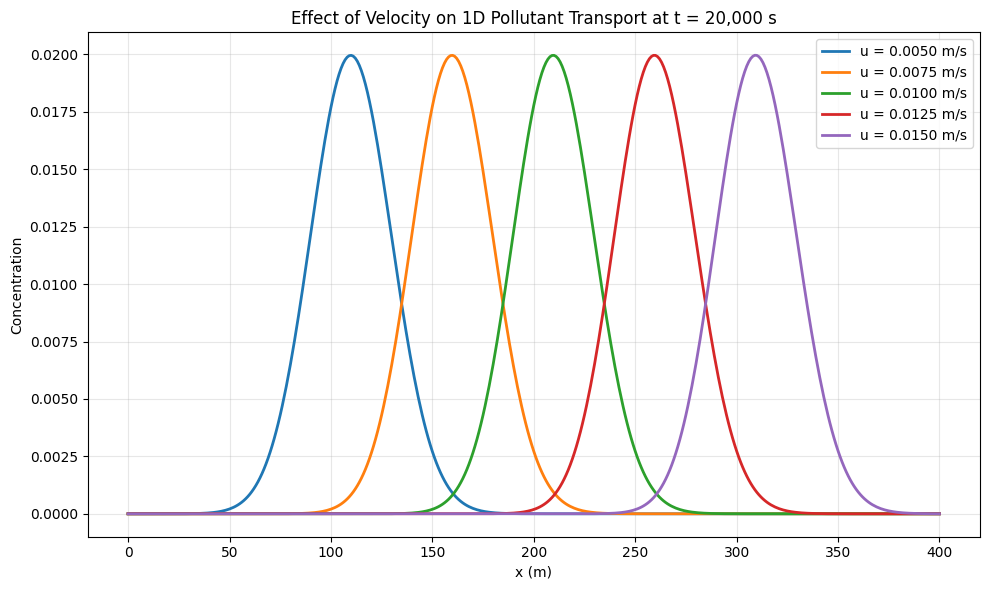

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Velocity_Profiles.png


In [52]:

# FINAL FIGURE:
# EFFECT OF VELOCITY ON 1D CONCENTRATION PROFILE


comparison_time = 20000

plt.figure(figsize=(10, 6))

for velocity_value in sorted(
    velocity_1d_profiles["Velocity"].unique()
):

    case_data = velocity_1d_profiles[
        (velocity_1d_profiles["Time_s"] == comparison_time)
        &
        (velocity_1d_profiles["Velocity"] == velocity_value)
    ]

    plt.plot(
        case_data["x_m"],
        case_data["NumericalConcentration"],
        linewidth=2,
        label=f"u = {velocity_value:.4f} m/s"
    )

plt.xlabel("x (m)")
plt.ylabel("Concentration")

plt.title(
    "Effect of Velocity on 1D Pollutant Transport "
    "at t = 20,000 s"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Velocity_Profiles.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

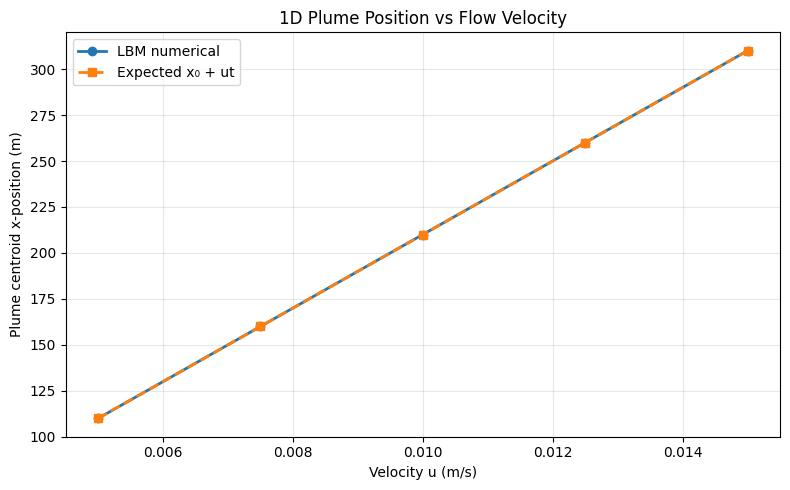

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Velocity_Centroid.png


In [54]:

# FINAL FIGURE:
# PLUME POSITION VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["NumericalCentroidX_m"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["ExpectedCentroidX_m"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Expected x₀ + ut"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume centroid x-position (m)")

plt.title(
    "1D Plume Position vs Flow Velocity"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Velocity_Centroid.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

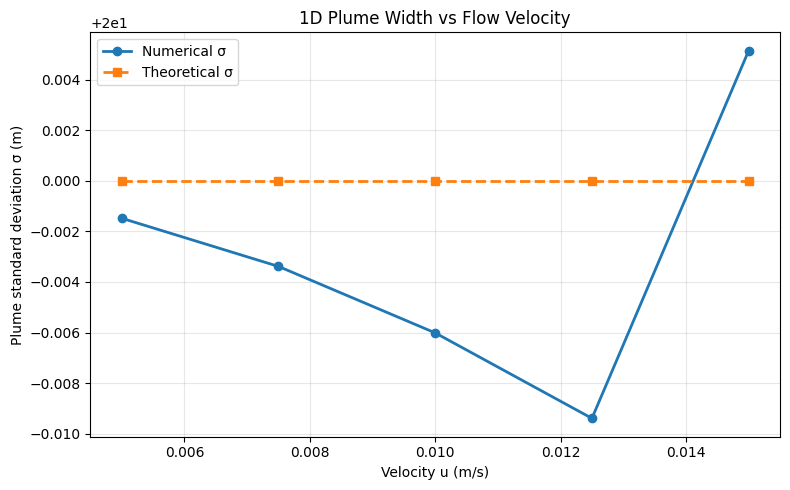

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Velocity_Sigma.png


In [56]:

# FINAL FIGURE:
# PLUME WIDTH VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["NumericalSigma_m"],
    marker="o",
    linewidth=2,
    label="Numerical σ"
)

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["TheoreticalSigma_m"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume standard deviation σ (m)")

plt.title(
    "1D Plume Width vs Flow Velocity"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Velocity_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

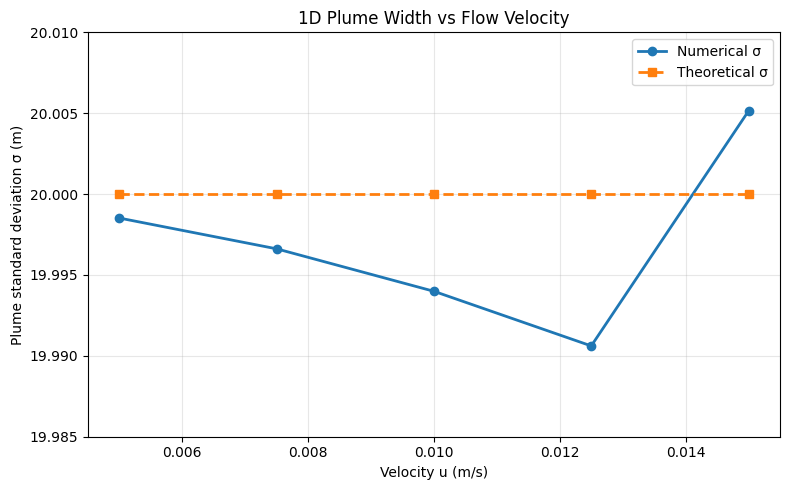

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Velocity_Sigma.png


In [62]:

# FINAL FIGURE:
# PLUME WIDTH VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["NumericalSigma_m"],
    marker="o",
    linewidth=2,
    label="Numerical σ"
)

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["TheoreticalSigma_m"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume standard deviation σ (m)")

plt.title(
    "1D Plume Width vs Flow Velocity"
)

plt.ylim(19.985, 20.010)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Velocity_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

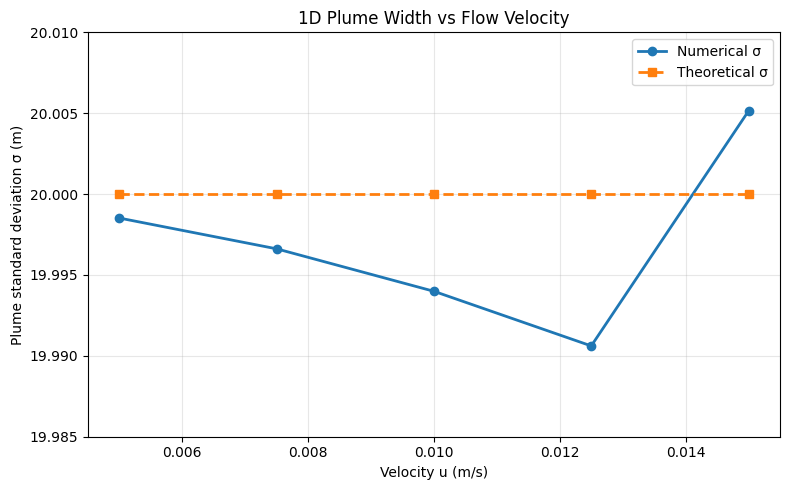

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Velocity_Sigma.png


In [66]:

# FINAL FIGURE:
# PLUME WIDTH VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["NumericalSigma_m"],
    marker="o",
    linewidth=2,
    label="Numerical σ"
)

plt.plot(
    velocity_1d_20000["Velocity"],
    velocity_1d_20000["TheoreticalSigma_m"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume standard deviation σ (m)")

plt.title(
    "1D Plume Width vs Flow Velocity"
)

plt.ylim(19.985, 20.010)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Velocity_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [68]:

# LOAD LOW-DIFFUSION SNAPSHOT RESULTS


low_diffusion_snapshots = pd.read_csv(
    results_folder
    / "1D_Low_Diffusion_Diagnostic"
    / "1D_low_diffusion_snapshot_summary.csv"
)

print("Snapshot dataset shape:")
print(low_diffusion_snapshots.shape)

print("\nColumn names:")
for column in low_diffusion_snapshots.columns:
    print(column)

print("\nFirst 10 rows:")
print(low_diffusion_snapshots.head(10))

Snapshot dataset shape:
(20, 11)

Column names:
Snapshot_Diffusion
Snapshot_Peclet
Snapshot_Time_s
Snapshot_MinimumC
Snapshot_MaximumC
Snapshot_NegativeCount
Snapshot_RMSE
Snapshot_MAE
Snapshot_R2
Snapshot_Mass
Snapshot_HasNegativeC

First 10 rows:
   Snapshot_Diffusion  Snapshot_Peclet  Snapshot_Time_s  Snapshot_MinimumC  \
0               0.006         1.666667              100      -4.388202e-17   
1               0.006         1.666667             1000      -2.472117e-19   
2               0.006         1.666667             5000      -4.078717e-33   
3               0.006         1.666667            10000      -6.451067e-51   
4               0.005         2.000000              100      -3.371579e-02   
5               0.005         2.000000             1000      -9.082844e-04   
6               0.005         2.000000             5000      -3.559558e-07   
7               0.005         2.000000            10000      -2.554304e-10   
8               0.004         2.500000           

In [70]:

# DISPLAY LOW-DIFFUSION CASE SUMMARY


low_diffusion_1d[
    [
        "Diffusion",
        "Peclet",
        "InitialMinimumFeq",
        "InitialNegativePopulationCount",
        "FirstNegativeTime_s",
        "MostNegativeConcentration",
        "FinalMass",
        "StoppedEarly",
        "Status"
    ]
]

,Diffusion,Peclet,InitialMinimumFeq,InitialNegativePopulationCount,FirstNegativeTime_s,MostNegativeConcentration,FinalMass,StoppedEarly,Status
0,0.006,1.666667,-1.084202e-19,0,NaN,-4.510103e-17,1.0,0,Completed
1,0.005,2.000000,-8.333333e-05,5,0.1,-3.500260e-02,1.0,0,Completed
2,0.004,2.500000,-1.666667e-04,5,0.1,-8.206554e-02,1.0,0,Completed
3,0.003,3.333333,-2.500000e-04,5,0.1,-1.476964e-01,1.0,0,Completed
4,0.002,5.000000,-3.333333e-04,5,0.1,-2.434824e-01,1.0,0,Completed


In [76]:

# CHECK LOW-DIFFUSION DIAGNOSTIC VALUES AND TIMES


print("Diffusion values:")
print(
    sorted(
        low_diffusion_snapshots[
            "Snapshot_Diffusion"
        ].unique()
    )
)

print("\nPeclet numbers:")
print(
    sorted(
        low_diffusion_snapshots[
            "Snapshot_Peclet"
        ].unique()
    )
)

print("\nDiagnostic times:")
print(
    sorted(
        low_diffusion_snapshots[
            "Snapshot_Time_s"
        ].unique()
    )
)

print("\nRows for each diffusion value:")
print(
    low_diffusion_snapshots.groupby(
        "Snapshot_Diffusion"
    ).size()
)

Diffusion values:
[np.float64(0.002), np.float64(0.003), np.float64(0.004), np.float64(0.005), np.float64(0.006)]

Peclet numbers:
[np.float64(1.66666666666667), np.float64(2.0), np.float64(2.5), np.float64(3.33333333333333), np.float64(5.0)]

Diagnostic times:
[np.int64(100), np.int64(1000), np.int64(5000), np.int64(10000)]

Rows for each diffusion value:
Snapshot_Diffusion
0.002    4
0.003    4
0.004    4
0.005    4
0.006    4
dtype: int64


In [78]:

# DISPLAY LOW-DIFFUSION SNAPSHOT RESULTS


low_diffusion_snapshots[
    [
        "Snapshot_Diffusion",
        "Snapshot_Peclet",
        "Snapshot_Time_s",
        "Snapshot_MinimumC",
        "Snapshot_NegativeCount",
        "Snapshot_RMSE",
        "Snapshot_R2",
        "Snapshot_Mass",
        "Snapshot_HasNegativeC"
    ]
]

,Snapshot_Diffusion,Snapshot_Peclet,Snapshot_Time_s,Snapshot_MinimumC,Snapshot_NegativeCount,Snapshot_RMSE,Snapshot_R2,Snapshot_Mass,Snapshot_HasNegativeC
0,0.006,1.666667,100,-4.388202e-17,0,0.009687,0.852438,1.000000,0
1,0.006,1.666667,1000,-2.472117e-19,0,0.001328,0.991039,1.000000,0
2,0.006,1.666667,5000,-4.078717e-33,0,0.000390,0.998205,1.000000,0
3,0.006,1.666667,10000,-6.451067e-51,0,0.000231,0.999078,1.000000,0
4,0.005,2.000000,100,-3.371579e-02,4,0.012024,0.792657,1.000000,1
5,0.005,2.000000,1000,-9.082844e-04,6,0.001807,0.984905,1.000000,1
6,0.005,2.000000,5000,-3.559558e-07,9,0.000535,0.996930,1.000000,1
7,0.005,2.000000,10000,-2.554304e-10,7,0.000318,0.998425,1.000000,1
8,0.004,2.500000,100,-7.628626e-02,5,0.015269,0.701449,1.000000,1
9,0.004,2.500000,1000,-5.117255e-03,8,0.002614,0.971830,1.000000,1


In [80]:

# DISPLAY LOW-DIFFUSION CASE SUMMAR

low_diffusion_1d[
    [
        "Diffusion",
        "Peclet",
        "InitialMinimumFeq",
        "InitialNegativePopulationCount",
        "FirstNegativeTime_s",
        "MostNegativeConcentration",
        "FinalMass",
        "StoppedEarly",
        "Status"
    ]
]

,Diffusion,Peclet,InitialMinimumFeq,InitialNegativePopulationCount,FirstNegativeTime_s,MostNegativeConcentration,FinalMass,StoppedEarly,Status
0,0.006,1.666667,-1.084202e-19,0,NaN,-4.510103e-17,1.0,0,Completed
1,0.005,2.000000,-8.333333e-05,5,0.1,-3.500260e-02,1.0,0,Completed
2,0.004,2.500000,-1.666667e-04,5,0.1,-8.206554e-02,1.0,0,Completed
3,0.003,3.333333,-2.500000e-04,5,0.1,-1.476964e-01,1.0,0,Completed
4,0.002,5.000000,-3.333333e-04,5,0.1,-2.434824e-01,1.0,0,Completed


In [82]:

# LOW-DIFFUSION RESULTS AT t = 10,000 


low_diffusion_10000 = (
    low_diffusion_snapshots[
        low_diffusion_snapshots["Snapshot_Time_s"] == 10000
    ]
    .sort_values("Snapshot_Diffusion")
    .reset_index(drop=True)
)

low_diffusion_10000[
    [
        "Snapshot_Diffusion",
        "Snapshot_Peclet",
        "Snapshot_MinimumC",
        "Snapshot_NegativeCount",
        "Snapshot_RMSE",
        "Snapshot_R2",
        "Snapshot_Mass",
        "Snapshot_HasNegativeC"
    ]
]

,Snapshot_Diffusion,Snapshot_Peclet,Snapshot_MinimumC,Snapshot_NegativeCount,Snapshot_RMSE,Snapshot_R2,Snapshot_Mass,Snapshot_HasNegativeC
0,0.002,5.000000,-2.367548e-03,40,0.001529,0.977734,1.0,1
1,0.003,3.333333,-1.472601e-04,23,0.000771,0.992977,1.0,1
2,0.004,2.500000,-1.670582e-06,15,0.000469,0.996966,1.0,1
3,0.005,2.000000,-2.554304e-10,7,0.000318,0.998425,1.0,1
4,0.006,1.666667,-6.451067e-51,0,0.000231,0.999078,1.0,0


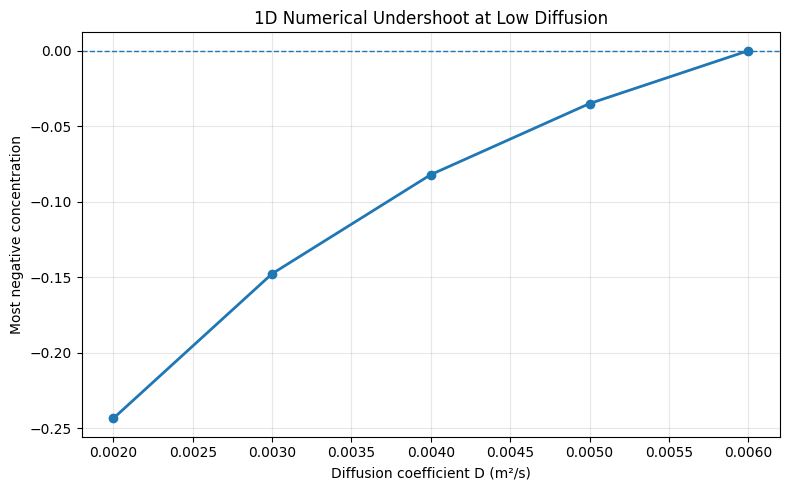

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Low_Diffusion_Undershoot.png


In [84]:

# FINAL FIGURE:
# WORST NEGATIVE CONCENTRATION VS DIFFUSION

plt.figure(figsize=(8, 5))

plt.plot(
    low_diffusion_1d["Diffusion"],
    low_diffusion_1d["MostNegativeConcentration"],
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Most negative concentration")

plt.title(
    "1D Numerical Undershoot at Low Diffusion"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Low_Diffusion_Undershoot.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

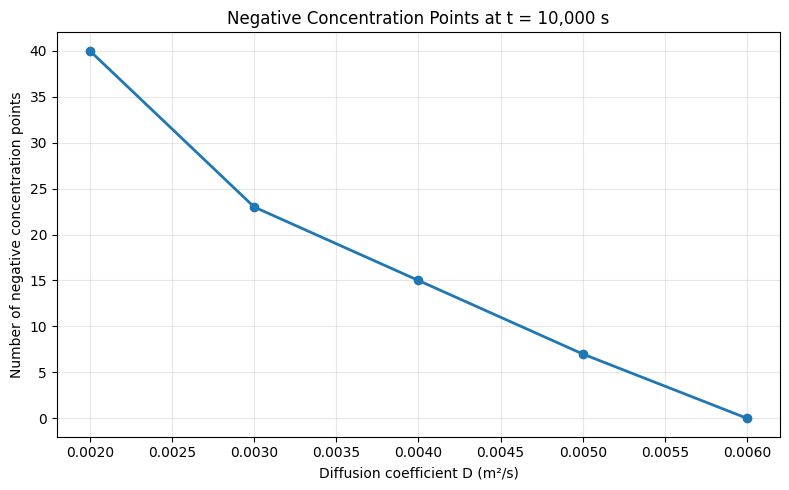

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Low_Diffusion_Negative_Points.png


In [86]:

# FINAL FIGURE:
# NEGATIVE CONCENTRATION POINTS VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    low_diffusion_10000["Snapshot_Diffusion"],
    low_diffusion_10000["Snapshot_NegativeCount"],
    marker="o",
    linewidth=2
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Number of negative concentration points")

plt.title(
    "Negative Concentration Points at t = 10,000 s"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Low_Diffusion_Negative_Points.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

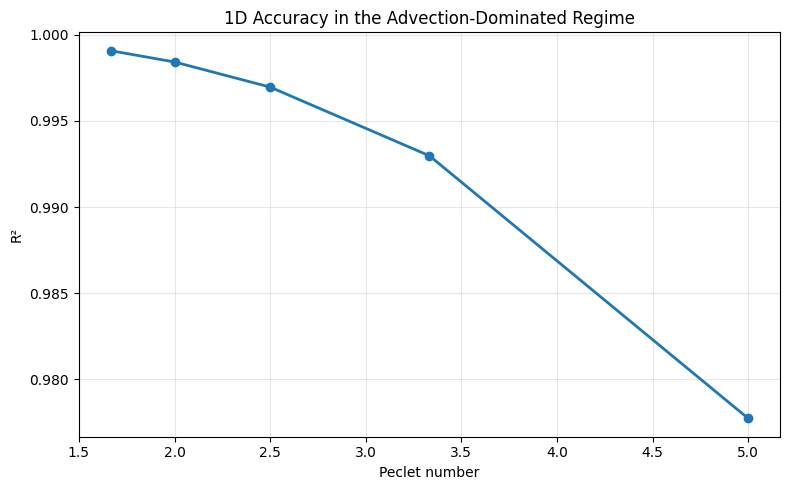

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_1D_Low_Diffusion_R2_vs_Peclet.png


In [88]:

# FINAL FIGURE:
# R² VS PECLET NUMBER AT t = 10,000 s


low_diffusion_pe = (
    low_diffusion_10000
    .sort_values("Snapshot_Peclet")
)

plt.figure(figsize=(8, 5))

plt.plot(
    low_diffusion_pe["Snapshot_Peclet"],
    low_diffusion_pe["Snapshot_R2"],
    marker="o",
    linewidth=2
)

plt.xlabel("Peclet number")
plt.ylabel("R²")

plt.title(
    "1D Accuracy in the Advection-Dominated Regime"
)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_1D_Low_Diffusion_R2_vs_Peclet.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [90]:

# LOAD 2D BENCHMARK PROFILE DATA


benchmark_2d_profiles = pd.read_csv(
    results_folder
    / "2D_Benchmark"
    / "2D_benchmark_profiles.csv"
)

print("2D benchmark profile shape:")
print(benchmark_2d_profiles.shape)

print("\nColumn names:")
for column in benchmark_2d_profiles.columns:
    print(column)

print("\nFirst 10 rows:")
print(benchmark_2d_profiles.head(10))

2D benchmark profile shape:
(120000, 6)

Column names:
Time_s
x_m
y_m
NumericalConcentration
AnalyticalConcentration
Error

First 10 rows:
   Time_s  x_m  y_m  NumericalConcentration  AnalyticalConcentration  \
0    2000    0    0            9.323200e-13             2.349646e-12   
1    2000    1    0            1.351159e-12             3.397414e-12   
2    2000    2    0            1.932290e-12             4.851387e-12   
3    2000    3    0            2.727120e-12             6.841552e-12   
4    2000    4    0            3.798759e-12             9.528284e-12   
5    2000    5    0            5.223019e-12             1.310527e-11   
6    2000    6    0            7.088893e-12             1.780118e-11   
7    2000    7    0            9.498277e-12             2.387936e-11   
8    2000    8    0            1.256468e-11             3.163502e-11   
9    2000    9    0            1.641068e-11             4.138898e-11   

          Error  
0 -1.417326e-12  
1 -2.046255e-12  
2 -2.919097e-1

In [92]:

# CHECK 2D BENCHMARK SNAPSHOT TIMES


print("2D benchmark summary times:")
print(
    sorted(
        benchmark_2d["Time_s"].unique()
    )
)

print("\n2D benchmark summary:")
display(
    benchmark_2d[
        [
            "Time_s",
            "RMSE",
            "MAE",
            "R2",
            "NumericalMass",
            "AnalyticalMass",
            "NumericalPeakX",
            "NumericalPeakY",
            "ExpectedCentroidX",
            "ExpectedCentroidY",
            "SigmaX",
            "SigmaY",
            "TheoreticalSigma",
            "NegativePointCount"
        ]
    ]
)

2D benchmark summary times:
[np.int64(2000), np.int64(4000), np.int64(6000), np.int64(8000), np.int64(10000), np.int64(12000)]

2D benchmark summary:


,Time_s,RMSE,MAE,R2,NumericalMass,AnalyticalMass,NumericalPeakX,NumericalPeakY,ExpectedCentroidX,ExpectedCentroidY,SigmaX,SigmaY,TheoreticalSigma,NegativePointCount
0,2000,1.014253e-06,2.407047e-07,0.999978,1.0,1.0,30,50,30,50,8.945267,8.945379,8.944272,0
1,4000,4.152689e-07,1.404956e-07,0.999992,1.0,1.0,50,50,50,50,12.649735,12.648370,12.649111,0
2,6000,2.532091e-07,1.056549e-07,0.999995,1.0,1.0,70,50,70,50,15.492379,15.460544,15.491933,0
3,8000,1.800260e-07,8.630963e-08,0.999997,1.0,1.0,90,50,90,50,17.888874,17.736711,17.888544,0
4,10000,1.389367e-07,7.440772e-08,0.999997,1.0,1.0,110,50,110,50,20.000227,19.599863,20.000000,0
5,12000,1.134357e-07,6.659582e-08,0.999998,1.0,1.0,130,50,130,50,21.908895,21.128914,21.908902,0


In [96]:

# HELPER FUNCTION:
# CONVERT LONG-FORM PROFILE DATA TO 2D GRID

def get_2d_benchmark_field(time_value, column_name):

    data_time = benchmark_2d_profiles[
        benchmark_2d_profiles["Time_s"] == time_value
    ]

    field = (
        data_time
        .pivot(
            index="y_m",
            columns="x_m",
            values=column_name
        )
        .sort_index()
        .sort_index(axis=1)
    )

    x_values = field.columns.to_numpy()
    y_values = field.index.to_numpy()

    return x_values, y_values, field.to_numpy()

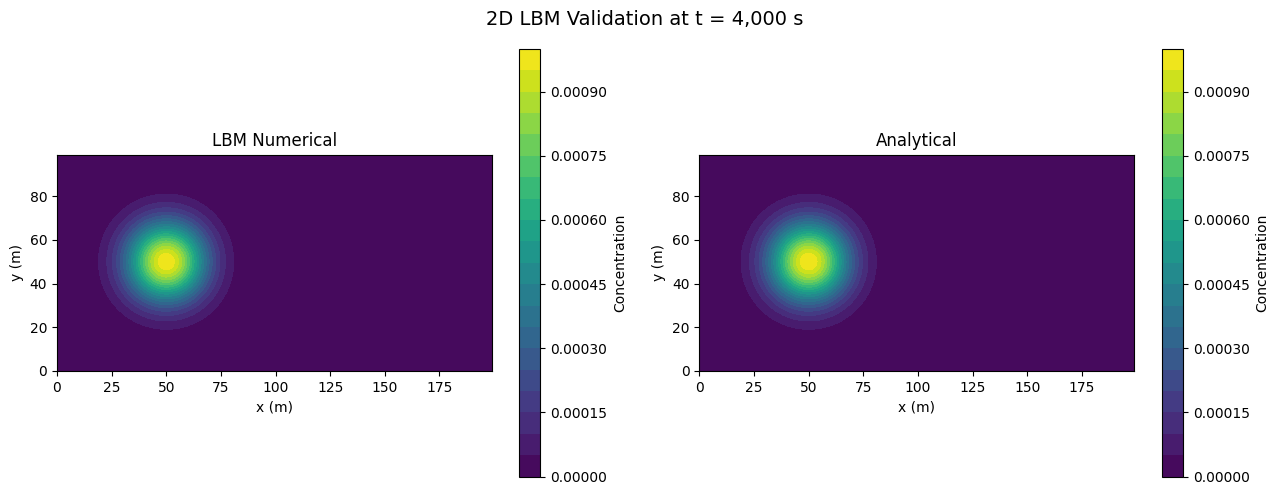

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Benchmark_4000s.png


In [98]:

# FINAL FIGURE:
# 2D BENCHMARK AT t = 4000 s


time_value = 4000

x_values, y_values, numerical = (
    get_2d_benchmark_field(
        time_value,
        "NumericalConcentration"
    )
)

_, _, analytical = (
    get_2d_benchmark_field(
        time_value,
        "AnalyticalConcentration"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

levels = 20

contour_1 = axes[0].contourf(
    x_values,
    y_values,
    numerical,
    levels=levels
)

axes[0].set_title("LBM Numerical")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_aspect("equal")

fig.colorbar(
    contour_1,
    ax=axes[0],
    label="Concentration"
)

contour_2 = axes[1].contourf(
    x_values,
    y_values,
    analytical,
    levels=levels
)

axes[1].set_title("Analytical")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].set_aspect("equal")

fig.colorbar(
    contour_2,
    ax=axes[1],
    label="Concentration"
)

fig.suptitle(
    "2D LBM Validation at t = 4,000 s",
    fontsize=14
)

fig.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Benchmark_4000s.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

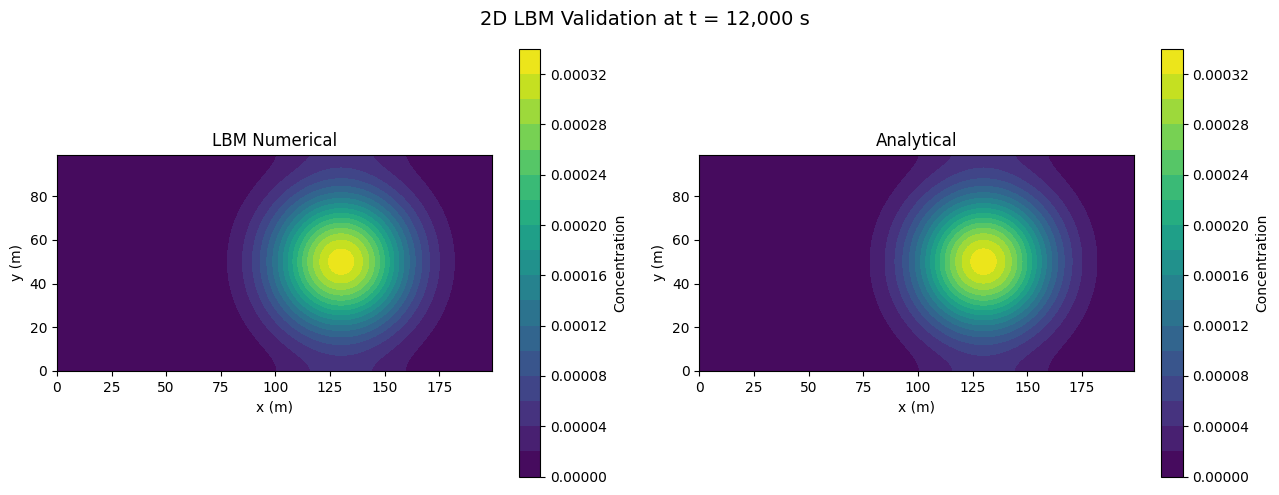

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Benchmark_12000s.png


In [100]:

# FINAL FIGURE:
# 2D BENCHMARK AT t = 12,000 s


time_value = 12000

x_values, y_values, numerical = (
    get_2d_benchmark_field(
        time_value,
        "NumericalConcentration"
    )
)

_, _, analytical = (
    get_2d_benchmark_field(
        time_value,
        "AnalyticalConcentration"
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

contour_1 = axes[0].contourf(
    x_values,
    y_values,
    numerical,
    levels=20
)

axes[0].set_title("LBM Numerical")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_aspect("equal")

fig.colorbar(
    contour_1,
    ax=axes[0],
    label="Concentration"
)

contour_2 = axes[1].contourf(
    x_values,
    y_values,
    analytical,
    levels=20
)

axes[1].set_title("Analytical")
axes[1].set_xlabel("x (m)")
axes[1].set_ylabel("y (m)")
axes[1].set_aspect("equal")

fig.colorbar(
    contour_2,
    ax=axes[1],
    label="Concentration"
)

fig.suptitle(
    "2D LBM Validation at t = 12,000 s",
    fontsize=14
)

fig.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Benchmark_12000s.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

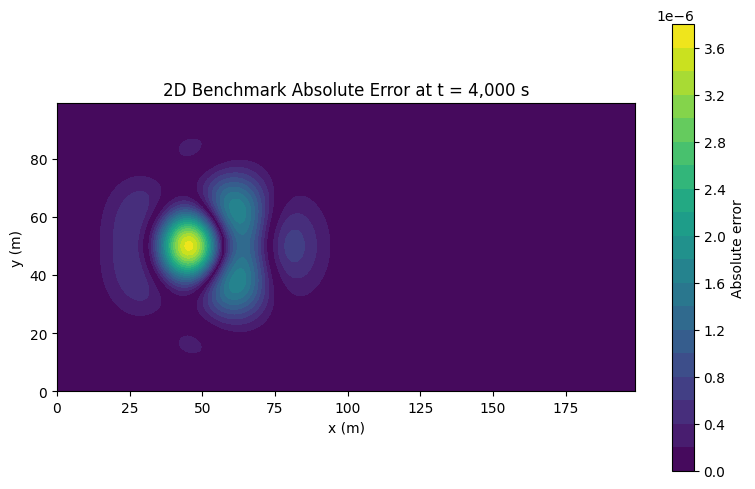

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Benchmark_Absolute_Error_4000s.png


In [102]:

# FINAL FIGURE:
# 2D ABSOLUTE ERROR AT t = 4000 s


time_value = 4000

x_values, y_values, error_field = (
    get_2d_benchmark_field(
        time_value,
        "Error"
    )
)

absolute_error = np.abs(error_field)

plt.figure(figsize=(8, 5))

contour = plt.contourf(
    x_values,
    y_values,
    absolute_error,
    levels=20
)

plt.colorbar(
    contour,
    label="Absolute error"
)

plt.xlabel("x (m)")
plt.ylabel("y (m)")

plt.title(
    "2D Benchmark Absolute Error at t = 4,000 s"
)

plt.gca().set_aspect("equal")

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Benchmark_Absolute_Error_4000s.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

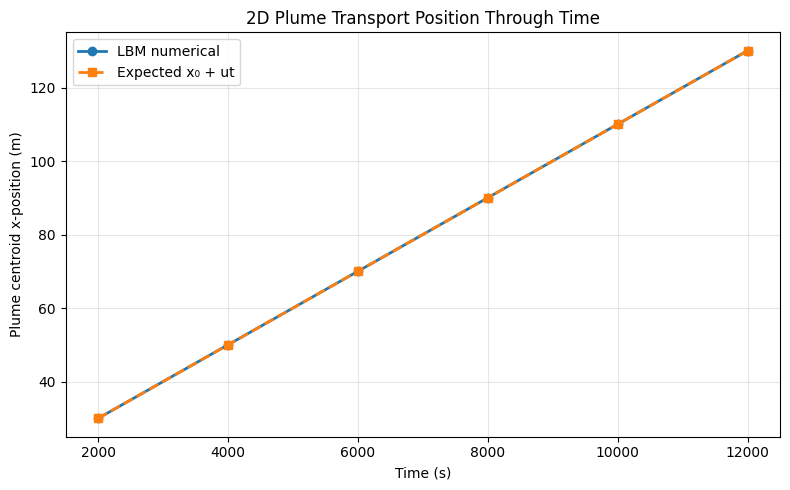

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Benchmark_Centroid.png


In [104]:

# FINAL FIGURE:
# NUMERICAL VS EXPECTED PLUME CENTRE


plt.figure(figsize=(8, 5))

plt.plot(
    benchmark_2d["Time_s"],
    benchmark_2d["NumericalCentroidX"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    benchmark_2d["Time_s"],
    benchmark_2d["ExpectedCentroidX"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Expected x₀ + ut"
)

plt.xlabel("Time (s)")
plt.ylabel("Plume centroid x-position (m)")

plt.title(
    "2D Plume Transport Position Through Time"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Benchmark_Centroid.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [106]:

# DISPLAY 2D DIFFUSION RESULTS


diffusion_2d_display = (
    diffusion_2d
    .sort_values("Diffusion")
    .reset_index(drop=True)
)

diffusion_2d_display[
    [
        "Diffusion",
        "Peclet",
        "NumericalPeak",
        "AnalyticalPeak",
        "SigmaX",
        "SigmaY",
        "TheoreticalSigma",
        "RMSE",
        "R2",
        "MinimumC",
        "NegativePointCount",
        "NumericalMass"
    ]
]

,Diffusion,Peclet,NumericalPeak,AnalyticalPeak,SigmaX,SigmaY,TheoreticalSigma,RMSE,R2,MinimumC,NegativePointCount,NumericalMass
0,0.002,5.000000,0.009547,0.009947,3.999749,4.000247,4.000000,3.428965e-05,0.995224,-4.947138e-05,729,1.0
1,0.005,2.000000,0.003927,0.003979,6.324631,6.324947,6.324555,5.786719e-06,0.999655,-2.832421e-09,221,1.0
2,0.010,1.000000,0.001977,0.001989,8.944602,8.944825,8.944272,1.526966e-06,0.999951,-1.745200e-16,0,1.0
3,0.015,0.666667,0.001321,0.001326,10.954947,10.955058,10.954451,7.097654e-07,0.999984,-1.104377e-23,0,1.0
4,0.020,0.500000,0.000992,0.000995,12.649735,12.648370,12.649111,4.152689e-07,0.999992,5.027832e-21,0,1.0


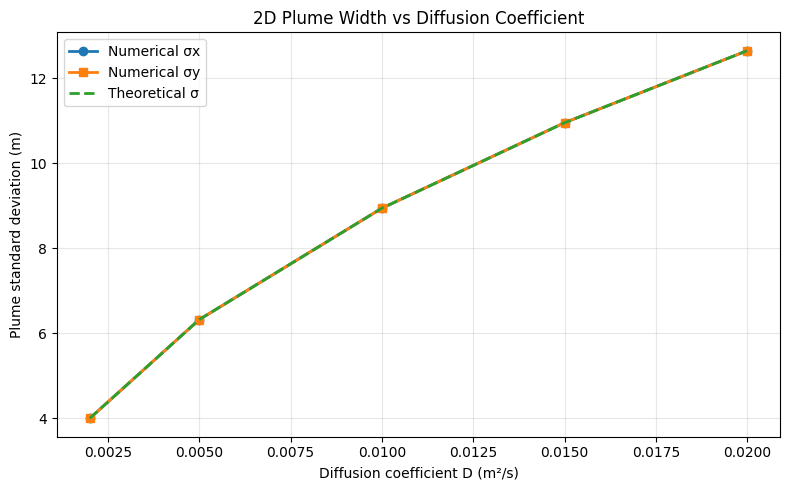

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Diffusion_Sigma.png


In [108]:

# FINAL FIGURE:
# 2D PLUME WIDTH VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["SigmaX"],
    marker="o",
    linewidth=2,
    label="Numerical σx"
)

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["SigmaY"],
    marker="s",
    linewidth=2,
    label="Numerical σy"
)

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["TheoreticalSigma"],
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Plume standard deviation (m)")

plt.title(
    "2D Plume Width vs Diffusion Coefficient"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Diffusion_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

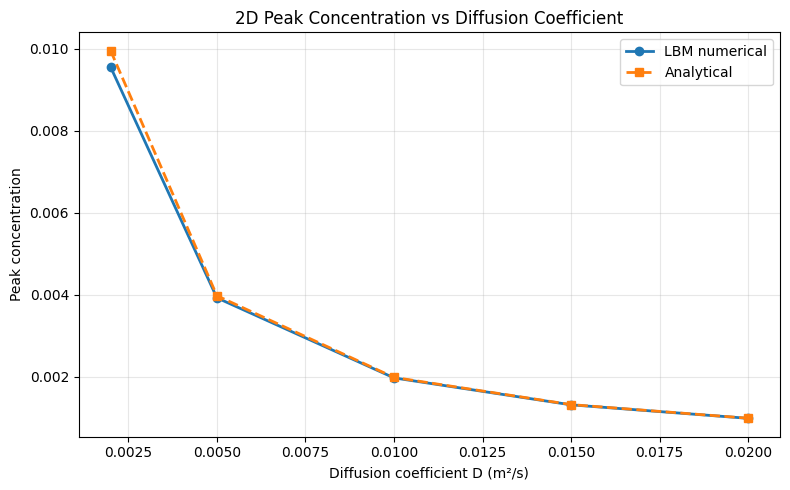

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Diffusion_Peak.png


In [110]:

# FINAL FIGURE:
# 2D PEAK CONCENTRATION VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["NumericalPeak"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["AnalyticalPeak"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Peak concentration")

plt.title(
    "2D Peak Concentration vs Diffusion Coefficient"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Diffusion_Peak.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

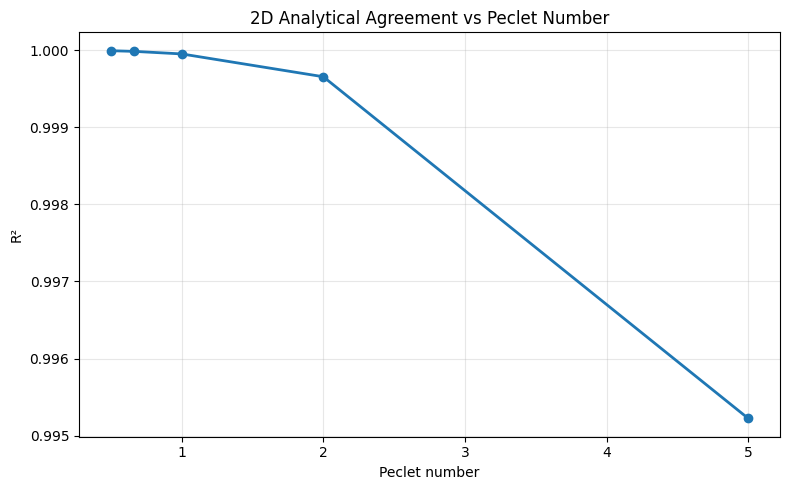

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Diffusion_R2_vs_Peclet.png


In [112]:

# FINAL FIGURE:
# 2D ACCURACY VS PECLET NUMBER


diffusion_2d_pe = (
    diffusion_2d_display
    .sort_values("Peclet")
)

plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_2d_pe["Peclet"],
    diffusion_2d_pe["R2"],
    marker="o",
    linewidth=2
)

plt.xlabel("Peclet number")
plt.ylabel("R²")

plt.title(
    "2D Analytical Agreement vs Peclet Number"
)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Diffusion_R2_vs_Peclet.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

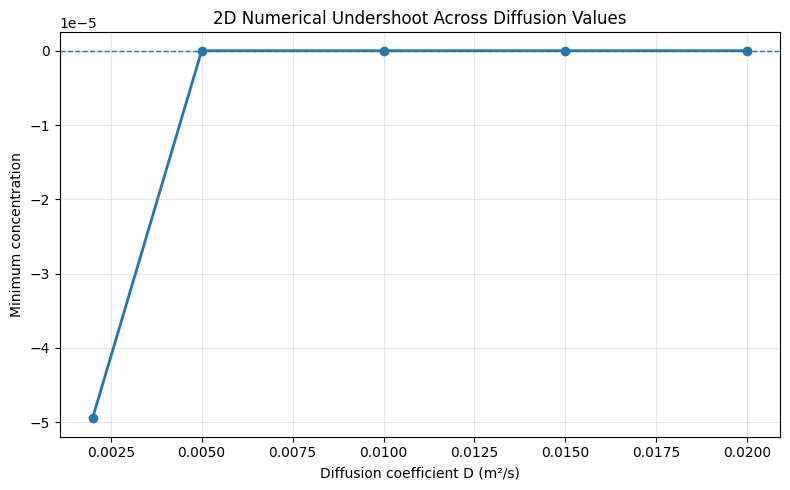

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Diffusion_Minimum_Concentration.png


In [114]:

# FINAL FIGURE:
# 2D MINIMUM CONCENTRATION VS DIFFUSION


plt.figure(figsize=(8, 5))

plt.plot(
    diffusion_2d_display["Diffusion"],
    diffusion_2d_display["MinimumC"],
    marker="o",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Diffusion coefficient D (m²/s)")
plt.ylabel("Minimum concentration")

plt.title(
    "2D Numerical Undershoot Across Diffusion Values"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Diffusion_Minimum_Concentration.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [116]:

# DISPLAY 2D VELOCITY RESULTS


velocity_2d_display = (
    velocity_2d
    .sort_values("Velocity")
    .reset_index(drop=True)
)

velocity_2d_display[
    [
        "Velocity",
        "Peclet",
        "CentroidX",
        "ExpectedCentreX",
        "CentroidErrorX",
        "NumericalPeak",
        "AnalyticalPeak",
        "SigmaX",
        "SigmaY",
        "TheoreticalSigma",
        "RMSE",
        "R2",
        "NegativePointCount",
        "NumericalMass"
    ]
]

,Velocity,Peclet,CentroidX,ExpectedCentreX,CentroidErrorX,NumericalPeak,AnalyticalPeak,SigmaX,SigmaY,TheoreticalSigma,RMSE,R2,NegativePointCount,NumericalMass
0,0.0050,0.250,30.001404,30,0.001404,0.000992,0.000995,12.649854,12.64837,12.649111,3.281413e-07,0.999995,0,1.0
1,0.0075,0.375,40.002106,40,0.002106,0.000992,0.000995,12.649805,12.64837,12.649111,3.669660e-07,0.999994,0,1.0
2,0.0100,0.500,50.002808,50,0.002808,0.000992,0.000995,12.649735,12.64837,12.649111,4.152689e-07,0.999992,0,1.0
3,0.0125,0.625,60.003511,60,0.003511,0.000992,0.000995,12.649647,12.64837,12.649111,4.701397e-07,0.999990,0,1.0
4,0.0150,0.750,70.004213,70,0.004213,0.000992,0.000995,12.649538,12.64837,12.649111,5.295430e-07,0.999987,0,1.0


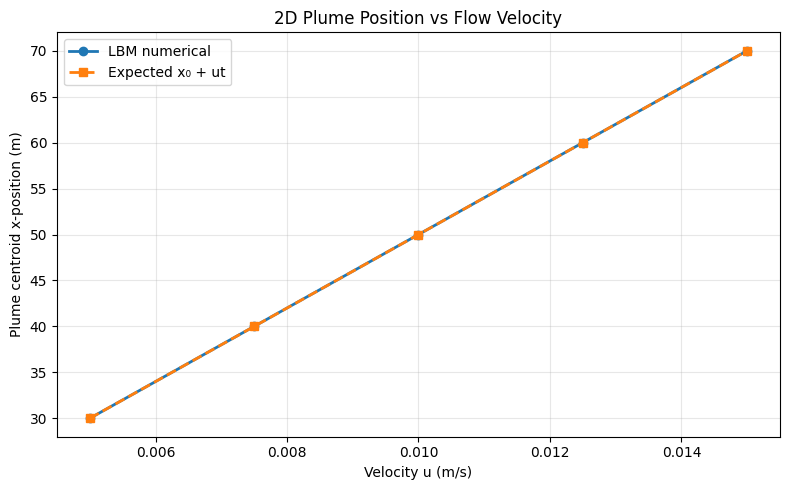

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Velocity_Centroid.png


In [118]:

# FINAL FIGURE:
# 2D PLUME POSITION VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["CentroidX"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["ExpectedCentreX"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Expected x₀ + ut"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume centroid x-position (m)")

plt.title(
    "2D Plume Position vs Flow Velocity"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Velocity_Centroid.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

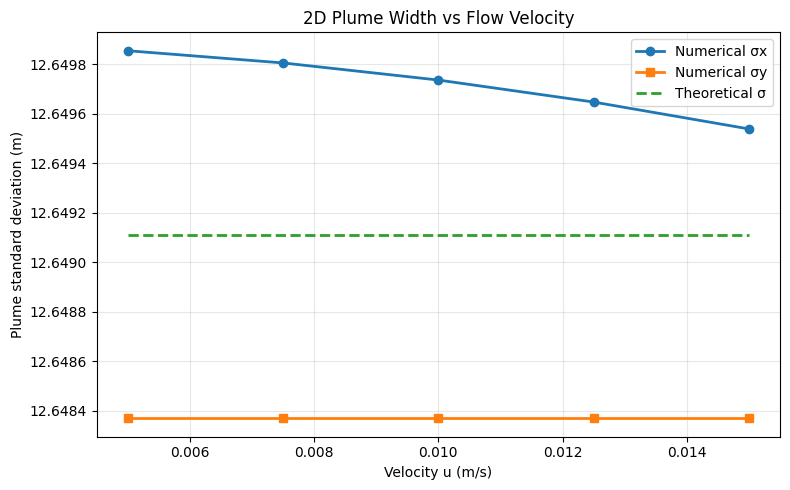

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Velocity_Sigma.png


In [120]:

# FINAL FIGURE:
# 2D PLUME WIDTH VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["SigmaX"],
    marker="o",
    linewidth=2,
    label="Numerical σx"
)

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["SigmaY"],
    marker="s",
    linewidth=2,
    label="Numerical σy"
)

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["TheoreticalSigma"],
    linestyle="--",
    linewidth=2,
    label="Theoretical σ"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Plume standard deviation (m)")

plt.title(
    "2D Plume Width vs Flow Velocity"
)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Velocity_Sigma.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

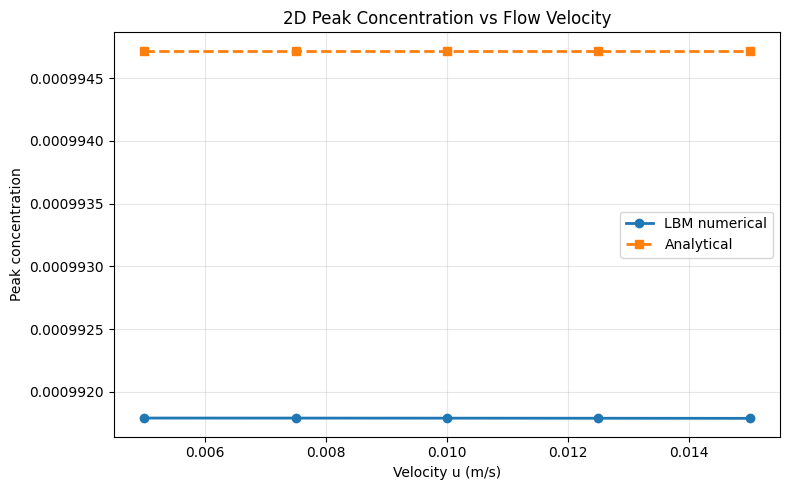

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Velocity_Peak.png


In [122]:

# FINAL FIGURE:
# 2D PEAK CONCENTRATION VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["NumericalPeak"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["AnalyticalPeak"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Analytical"
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Peak concentration")

plt.title(
    "2D Peak Concentration vs Flow Velocity"
)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Velocity_Peak.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

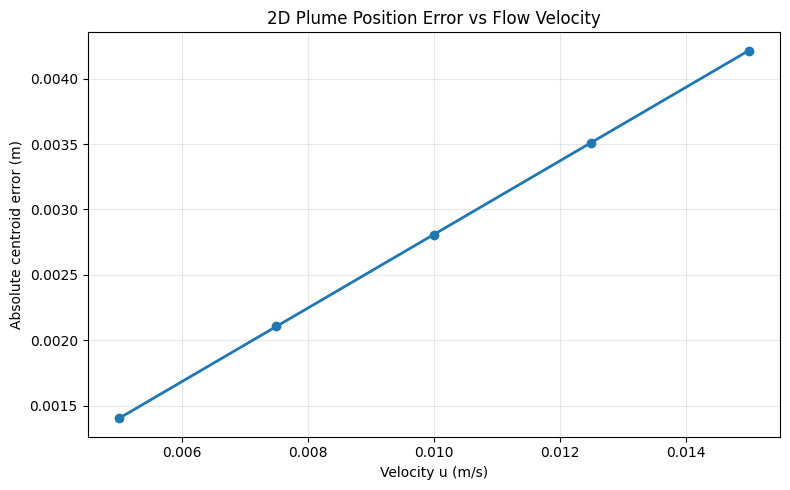

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_Velocity_Centroid_Error.png


In [124]:

# FINAL FIGURE:
# 2D CENTROID ERROR VS VELOCITY


plt.figure(figsize=(8, 5))

plt.plot(
    velocity_2d_display["Velocity"],
    velocity_2d_display["CentroidErrorX"],
    marker="o",
    linewidth=2
)

plt.xlabel("Velocity u (m/s)")
plt.ylabel("Absolute centroid error (m)")

plt.title(
    "2D Plume Position Error vs Flow Velocity"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_Velocity_Centroid_Error.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [126]:

# DISPLAY 2D CHANNEL WIDTH RESULTS


channel_width_2d_display = (
    channel_width_2d
    .sort_values("ChannelWidth")
    .reset_index(drop=True)
)

channel_width_2d_display[
    [
        "ChannelWidth",
        "GridLy",
        "SourceY",
        "PeakX",
        "PeakY",
        "CentroidX",
        "CentroidY",
        "ExpectedCentreX",
        "CentroidErrorX",
        "SigmaX",
        "SigmaY",
        "UnboundedSigma",
        "SigmaYRatio",
        "NumericalPeak",
        "MeanConcentration",
        "TotalMass",
        "NegativePointCount",
        "HasNegativeConcentration"
    ]
]

,ChannelWidth,GridLy,SourceY,PeakX,PeakY,CentroidX,CentroidY,ExpectedCentreX,CentroidErrorX,SigmaX,SigmaY,UnboundedSigma,SigmaYRatio,NumericalPeak,MeanConcentration,TotalMass,NegativePointCount,HasNegativeConcentration
0,20,21,10,50,10,50.002808,10,50,0.002808,12.649735,6.052723,12.649111,0.478510,0.001502,0.000238,1.0,0,0
1,30,31,15,50,15,50.002808,15,50,0.002808,12.649735,8.743156,12.649111,0.691207,0.001090,0.000161,1.0,0,0
2,40,41,20,50,20,50.002808,20,50,0.002808,12.649735,10.686855,12.649111,0.844870,0.001002,0.000122,1.0,0,0
3,60,61,30,50,30,50.002808,30,50,0.002808,12.649735,12.330390,12.649111,0.974803,0.000992,0.000082,1.0,0,0
4,100,101,50,50,50,50.002808,50,50,0.002808,12.649735,12.648588,12.649111,0.999959,0.000992,0.000050,1.0,0,0


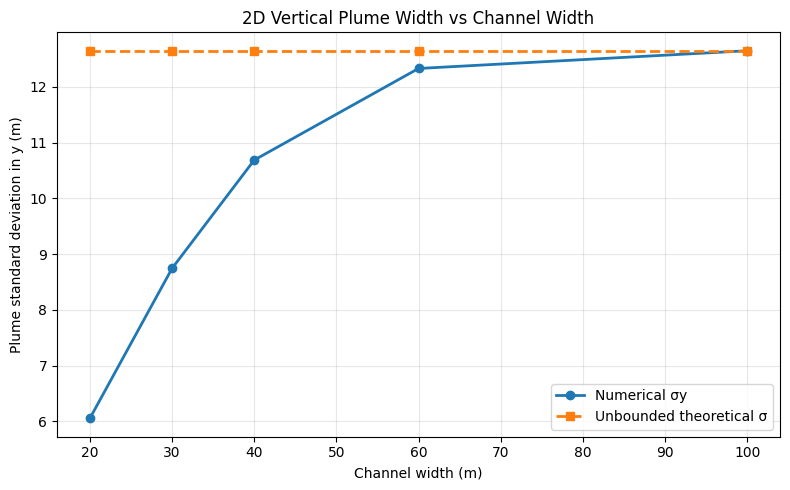

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_ChannelWidth_SigmaY.png


In [128]:
# ---------------------------------------------------------
# FINAL FIGURE:
# 2D PLUME WIDTH VS CHANNEL WIDTH
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["SigmaY"],
    marker="o",
    linewidth=2,
    label="Numerical σy"
)

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["UnboundedSigma"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Unbounded theoretical σ"
)

plt.xlabel("Channel width (m)")
plt.ylabel("Plume standard deviation in y (m)")

plt.title("2D Vertical Plume Width vs Channel Width")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_ChannelWidth_SigmaY.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

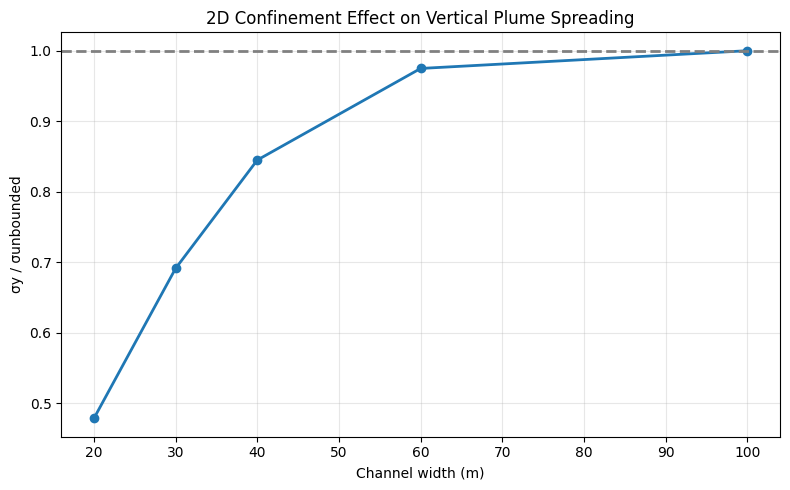

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_ChannelWidth_SigmaY_Ratio.png


In [130]:
# ---------------------------------------------------------
# FINAL FIGURE:
# CONFINEMENT EFFECT ON VERTICAL SPREADING
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["SigmaYRatio"],
    marker="o",
    linewidth=2
)

plt.axhline(
    1.0,
    linestyle="--",
    linewidth=2,
    color="gray"
)

plt.xlabel("Channel width (m)")
plt.ylabel("σy / σunbounded")

plt.title("2D Confinement Effect on Vertical Plume Spreading")

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_ChannelWidth_SigmaY_Ratio.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

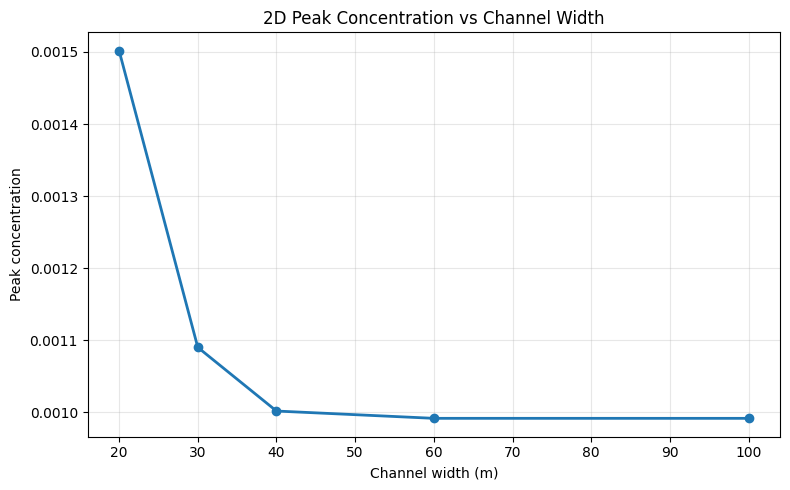

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_ChannelWidth_Peak.png


In [132]:
# ---------------------------------------------------------
# FINAL FIGURE:
# 2D PEAK CONCENTRATION VS CHANNEL WIDTH
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["NumericalPeak"],
    marker="o",
    linewidth=2
)

plt.xlabel("Channel width (m)")
plt.ylabel("Peak concentration")

plt.title("2D Peak Concentration vs Channel Width")

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_ChannelWidth_Peak.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

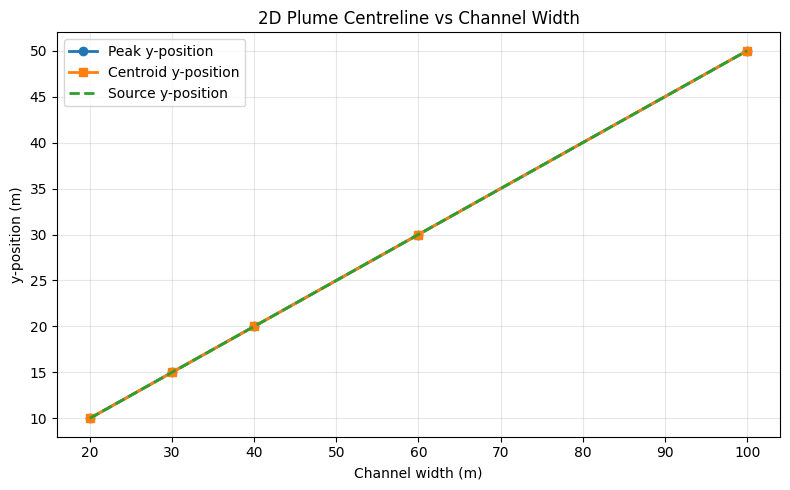

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_ChannelWidth_Centreline.png


In [134]:
# ---------------------------------------------------------
# FINAL FIGURE:
# 2D PLUME CENTRELINE VS CHANNEL WIDTH
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["PeakY"],
    marker="o",
    linewidth=2,
    label="Peak y-position"
)

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["CentroidY"],
    marker="s",
    linewidth=2,
    label="Centroid y-position"
)

plt.plot(
    channel_width_2d_display["ChannelWidth"],
    channel_width_2d_display["SourceY"],
    linestyle="--",
    linewidth=2,
    label="Source y-position"
)

plt.xlabel("Channel width (m)")
plt.ylabel("y-position (m)")

plt.title("2D Plume Centreline vs Channel Width")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_ChannelWidth_Centreline.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [136]:
# ---------------------------------------------------------
# DISPLAY 2D MULTIPLE-SOURCE RESULTS
# ---------------------------------------------------------

multiple_sources_2d_display = (
    multiple_sources_2d
    .sort_values("Time_s")
    .reset_index(drop=True)
)

multiple_sources_2d_display[
    [
        "Time_s",
        "RMSE",
        "MAE",
        "R2",
        "NumericalMass",
        "AnalyticalMass",
        "MassErrorPercent",
        "NumericalPeak",
        "AnalyticalPeak",
        "NumericalPeakX",
        "NumericalPeakY",
        "NumericalCentroidX",
        "NumericalCentroidY",
        "ExpectedCentroidX",
        "ExpectedCentroidY",
        "NegativePointCount"
    ]
]

,Time_s,RMSE,MAE,R2,NumericalMass,AnalyticalMass,MassErrorPercent,NumericalPeak,AnalyticalPeak,NumericalPeakX,NumericalPeakY,NumericalCentroidX,NumericalCentroidY,ExpectedCentroidX,ExpectedCentroidY,NegativePointCount
0,2000,1.734150e-06,6.329546e-07,0.999979,3.0,3.0,1.011043e-10,0.001997,0.002009,45,50,45.001404,50,45,50,0
1,3000,9.320646e-07,3.985103e-07,0.999991,3.0,3.0,1.518341e-10,0.001398,0.001403,55,50,55.002106,50,55,50,0
2,4000,6.067184e-07,2.921655e-07,0.999995,3.0,3.0,2.022234e-10,0.001132,0.001134,65,50,65.002808,50,65,50,0


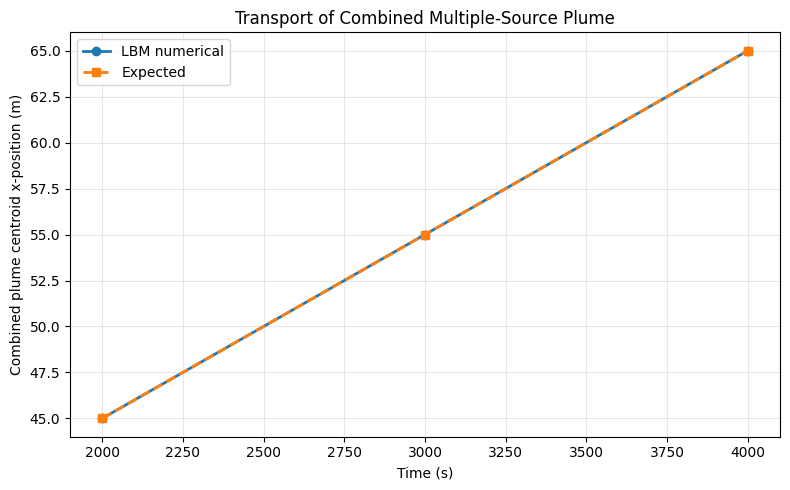

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_MultipleSources_Centroid.png


In [138]:
# ---------------------------------------------------------
# FINAL FIGURE:
# MULTIPLE-SOURCE CENTROID TRANSPORT
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    multiple_sources_2d_display["Time_s"],
    multiple_sources_2d_display["NumericalCentroidX"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    multiple_sources_2d_display["Time_s"],
    multiple_sources_2d_display["ExpectedCentroidX"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Expected"
)

plt.xlabel("Time (s)")
plt.ylabel("Combined plume centroid x-position (m)")

plt.title("Transport of Combined Multiple-Source Plume")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_MultipleSources_Centroid.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

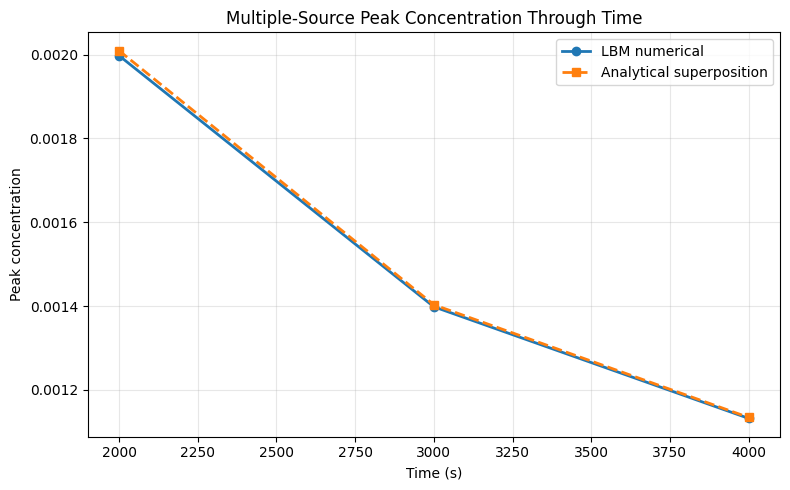

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_MultipleSources_Peak.png


In [140]:
# ---------------------------------------------------------
# FINAL FIGURE:
# MULTIPLE-SOURCE NUMERICAL VS ANALYTICAL PEAK
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    multiple_sources_2d_display["Time_s"],
    multiple_sources_2d_display["NumericalPeak"],
    marker="o",
    linewidth=2,
    label="LBM numerical"
)

plt.plot(
    multiple_sources_2d_display["Time_s"],
    multiple_sources_2d_display["AnalyticalPeak"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Analytical superposition"
)

plt.xlabel("Time (s)")
plt.ylabel("Peak concentration")

plt.title("Multiple-Source Peak Concentration Through Time")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_MultipleSources_Peak.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

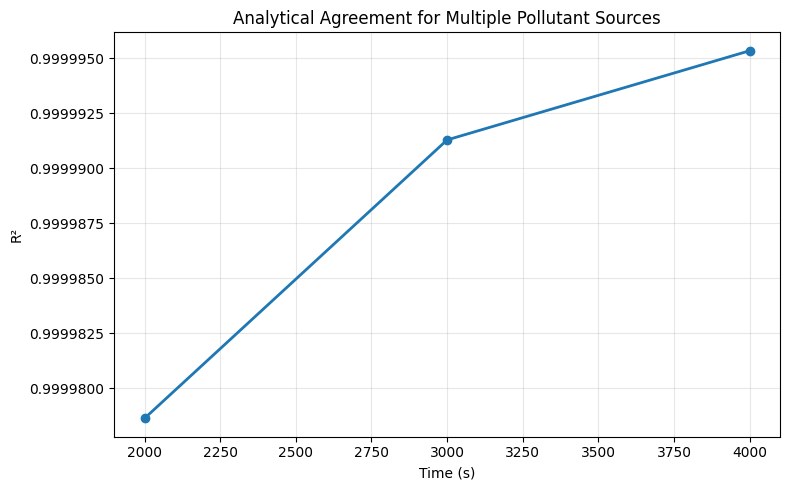

Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_2D_MultipleSources_R2.png


In [142]:
# ---------------------------------------------------------
# FINAL FIGURE:
# MULTIPLE-SOURCE ANALYTICAL AGREEMENT
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    multiple_sources_2d_display["Time_s"],
    multiple_sources_2d_display["R2"],
    marker="o",
    linewidth=2
)

plt.xlabel("Time (s)")
plt.ylabel("R²")

plt.title(
    "Analytical Agreement for Multiple Pollutant Sources"
)

plt.ticklabel_format(
    axis="y",
    style="plain",
    useOffset=False
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

output_file = (
    final_analysis_folder
    / "Final_2D_MultipleSources_R2.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(output_file)

In [144]:
# ---------------------------------------------------------
# FINAL PROJECT QUANTITATIVE SUMMARY
# ---------------------------------------------------------

final_project_summary = pd.DataFrame(
    {
        "Experiment": [
            "1D Benchmark",
            "1D Diffusion",
            "1D Velocity",
            "1D Low-Diffusion Stability",
            "2D Benchmark",
            "2D Diffusion",
            "2D Velocity",
            "2D Channel Width",
            "2D Multiple Sources"
        ],

        "Main_Result": [
            "LBM closely matched analytical 1D solution",
            "Higher D increased plume width and reduced peak",
            "Higher velocity translated plume downstream",
            "Low D caused non-physical negative concentrations",
            "LBM closely matched analytical 2D solution",
            "Higher D increased 2D spreading and reduced peak",
            "Higher velocity moved plume without changing width",
            "Narrow channels restricted lateral plume spreading",
            "LBM reproduced interaction of three pollutant sources"
        ],

        "Key_Quantitative_Result": [
            "R² = 0.99960–0.99992",
            "R² = 0.99952–0.99999 at 20,000 s",
            "Centroid = 110–310 m; σ ≈ 20 m",
            "D < 0.006 produced numerical undershoot",
            "R² = 0.999978–0.999998",
            "R² = 0.99522–0.99999",
            "Centroid error = 0.0014–0.0042 m",
            "σy/σunbounded = 0.4785–0.99996",
            "R² = 0.999979–0.999995; total mass = 3"
        ]
    }
)

display(final_project_summary)

output_file = (
    final_analysis_folder
    / "Final_Project_Quantitative_Summary.csv"
)

final_project_summary.to_csv(
    output_file,
    index=False
)

print("\nSaved:")
print(output_file)

,Experiment,Main_Result,Key_Quantitative_Result
0,1D Benchmark,LBM closely matched analytical 1D solution,R² = 0.99960–0.99992
1,1D Diffusion,Higher D increased plume width and reduced peak,"R² = 0.99952–0.99999 at 20,000 s"
2,1D Velocity,Higher velocity translated plume downstream,Centroid = 110–310 m; σ ≈ 20 m
3,1D Low-Diffusion Stability,Low D caused non-physical negative concentrations,D < 0.006 produced numerical undershoot
4,2D Benchmark,LBM closely matched analytical 2D solution,R² = 0.999978–0.999998
5,2D Diffusion,Higher D increased 2D spreading and reduced peak,R² = 0.99522–0.99999
6,2D Velocity,Higher velocity moved plume without changing w...,Centroid error = 0.0014–0.0042 m
7,2D Channel Width,Narrow channels restricted lateral plume sprea...,σy/σunbounded = 0.4785–0.99996
8,2D Multiple Sources,LBM reproduced interaction of three pollutant ...,R² = 0.999979–0.999995; total mass = 3



Saved:
/Users/abhishekkharat/Documents/MSc_LBM_Project/06_Results/Final_Analysis/Final_Project_Quantitative_Summary.csv


In [146]:
# ---------------------------------------------------------
# LIST ALL FINAL ANALYSIS FIGURES
# ---------------------------------------------------------

final_figures = sorted(
    final_analysis_folder.glob("*.png")
)

print(
    f"Number of final figures: {len(final_figures)}"
)

print("\nFinal figures:\n")

for figure in final_figures:
    print(figure.name)

Number of final figures: 33

Final figures:

Final_1D_Benchmark_R2.png
Final_1D_Benchmark_RMSE.png
Final_1D_Benchmark_Validation.png
Final_1D_Diffusion_Peak.png
Final_1D_Diffusion_Profiles.png
Final_1D_Diffusion_R2.png
Final_1D_Diffusion_Sigma.png
Final_1D_Low_Diffusion_Negative_Points.png
Final_1D_Low_Diffusion_R2_vs_Peclet.png
Final_1D_Low_Diffusion_Undershoot.png
Final_1D_Velocity_Centroid.png
Final_1D_Velocity_Peak.png
Final_1D_Velocity_Profiles.png
Final_1D_Velocity_Sigma.png
Final_2D_Benchmark_12000s.png
Final_2D_Benchmark_4000s.png
Final_2D_Benchmark_Absolute_Error_4000s.png
Final_2D_Benchmark_Centroid.png
Final_2D_ChannelWidth_Centreline.png
Final_2D_ChannelWidth_Peak.png
Final_2D_ChannelWidth_SigmaY.png
Final_2D_ChannelWidth_SigmaY_Ratio.png
Final_2D_Diffusion_Minimum_Concentration.png
Final_2D_Diffusion_Peak.png
Final_2D_Diffusion_R2_vs_Peclet.png
Final_2D_Diffusion_Sigma.png
Final_2D_MultipleSources_Centroid.png
Final_2D_MultipleSources_Peak.png
Final_2D_MultipleSources_R2.p